In [11]:
import pandas as pd
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [12]:
def summarize_hyperparam(env, mu_type, alg_names):
    def summ_ep(df):
        delta = df.delta.abs().mean()
        delta_obs = df.delta_obs.abs().mean()
        rew = df.sort_values("t")["resource"].values[-1]
        accept_g0 = df[df.group_id == 0].action.mean()
        accept_g1 = df[df.group_id == 1].action.mean()
        return pd.Series(
            {
                "delta": delta,
                "delta_obs": delta_obs,
                "reward": rew,
                "accept_g0": accept_g0,
                "accept_g1": accept_g1,
            }
        )

    files = [f"experiments/{env}/{mu_type}/{alg}/eval/eval_data.csv" for alg in alg_names]
    results = []
    for file in files:
        try:
            alg = file.split("/")[-3]
            df = pd.read_csv(file)
            df = df.groupby("ep").apply(summ_ep).aggregate(["mean", "std"])
            alg_simplified = alg.replace("sellf_hard", "sellf").split("_")[0]
            results.append(
                {
                    "alg": alg,
                    "alg_simplified": alg_simplified,
                    "delta": df["delta"]["mean"],
                    "delta_std": df["delta"]["std"],
                    "delta_obs": df["delta_obs"]["mean"],
                    "delta_obs_std": df["delta_obs"]["std"],
                    "reward": df["reward"]["mean"],
                    "reward_std": df["reward"]["std"],
                    "accept_g0": df["accept_g0"]["mean"],
                    "accept_g1": df["accept_g1"]["mean"],
                }
            )
        except:
            continue
    results = pd.DataFrame(results)

    results["minus_delta"] = 1 - results["delta"]

    delta_mean = results["minus_delta"].mean()
    delta_std = results["minus_delta"].std()

    reward_mean = results["reward"].mean()
    reward_std = results["reward"].std()

    results["score"] = (
        (results["minus_delta"] - delta_mean) / (delta_std) +
        (results["reward"] - reward_mean) / (reward_std)
    )
    return results

# FICO

In [32]:
env_name = "fico_equal"

## Ablation

In [ ]:
beta_1 = 5
selected_algs = [
    f"sellf(beta_1:{beta_1} beta_2:0)",
    f"sellf(beta_1:{beta_1} beta_2:0.05)",
    f"sellf(beta_1:{beta_1} beta_2:0.1)"
]

mu_type = "accuracy"

colors = ['#fbb4b9','#f768a1','#7a0177']


def legend_func(alg_name):
    alg_name = alg_name.split(" ")[1]
    alg_name = alg_name.replace("beta_2:", "$\\beta_2=$").replace(")", "")
    return alg_name


def color_func(alg_name):
    idx = selected_algs.index(alg_name)
    return colors[idx]

# first, get average delta of each algorithm
algs_deltas = {}
df_list = [pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv") for alg in selected_algs]
for i in range(len(df_list)):
    df_list[i]["delta"] = df_list[i]["delta"].abs()
    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "delta": "mean"
            }
        )
    ).agg(["mean", "std"])
    algs_deltas[selected_algs[i]] = {
        "mean": df_list[i]["delta"]["mean"],
        "std": df_list[i]["delta"]["std"]
    }


df_list = [pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/models/progress.csv") for alg in selected_algs]

fig, axs = plt.subplots(nrows = 1, ncols = 3, figsize = (12, 3))


window_size = 30
for i in range(len(df_list)):
    # make color be sequential
    reward = df_list[i]["reward"]
    reward = reward.rolling(window=window_size).mean()
    axs[0].plot(reward, color=colors[i])

    difference = (df_list[i]["delta"].abs() - df_list[i]["delta_obs"].abs()).abs()
    difference = difference.rolling(window=window_size).mean()
    axs[1].plot(difference, color=colors[i])


# bar plot of the average delta of each algorithm
axs[2].bar(
    [legend_func(alg) for alg in selected_algs],
    [algs_deltas[alg]["mean"] for alg in selected_algs],
    yerr=[algs_deltas[alg]["std"] for alg in selected_algs],
    color=colors,
)   
axs[2].set_xticklabels(
    [legend_func(alg)for alg in selected_algs],
    rotation=45,
)

#axs[1].set_ylim(-0.01, 0.01)
axs[1].axhline(0, color='black', linestyle='--', linewidth=1, alpha = 0.3)
for i in range(2):
    axs[i].set_xlabel("Learning iteration")
axs[0].set_ylabel("Average Reward")
axs[0].set_title("Reward")
axs[1].set_title("Difference between\ntrue and observed disparity")
axs[1].set_ylabel("$|\Delta| - |\\tilde \Delta |$")
axs[2].set_title("Disparity of learned policy")
axs[2].set_ylabel("Average Disparity ($\Delta_t$)")

# add legend to the first plot
axs[0].legend(
    [legend_func(alg) for alg in selected_algs],
    loc="center left",
    bbox_to_anchor=(-0.9, 0.6)
)
plt.tight_layout()
plt.savefig("figures/ablation.pdf", bbox_inches='tight')

FileNotFoundError: [Errno 2] No such file or directory: 'experiments/fico_equal/accuracy/sellf(beta_1:5 beta_2:0)/eval/eval_data.csv'

## Decomposition

In [34]:
alg = "serew(beta_1:1 beta_2:0)"
env_name = "enem"
mu_type = "accuracy"
df = pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/models/progress.csv")
df.columns

Index(['train/pred_lr', 'train/pred_reg', 'train/pred_loss',
       'train/explained_variance', 'train/error_rejected_g0',
       'train/error_bound_g1', 'train/delta', 'train/delta_pred_real',
       'train/error_bound_g0', 'train/accept_rate', 'train/value_loss',
       'train/loss', 'train/clip_fraction', 'train/delta_obs',
       'train/accuracy', 'train/accept_g0', 'train/error_rejected_g1',
       'train/accept_g1', 'train/policy_gradient_loss', 'train/approx_kl',
       'train/error_g0', 'train/reward', 'train/entropy_loss',
       'train/pos_rate', 'train/error_g1', 'train/divergence_g1',
       'train/delta_pred', 'train/divergence_g0'],
      dtype='object')

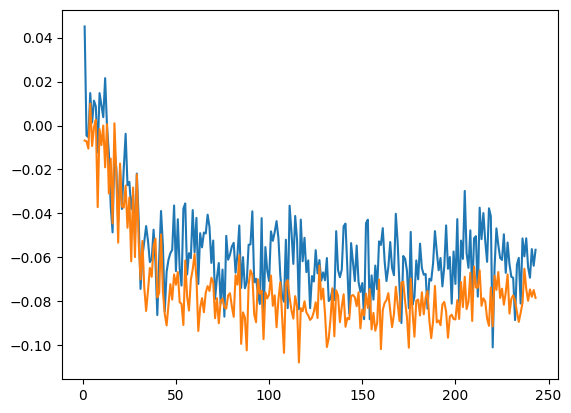

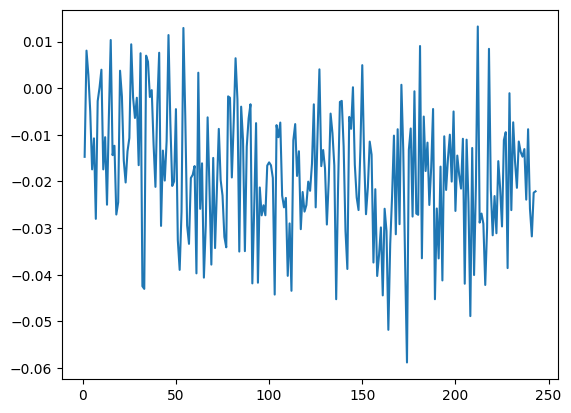

In [ ]:
plt.plot(df["delta_obs"])
plt.plot(df["delta"])
plt.show()

plt.plot(df["delta_pred_real"])
plt.show()


## Comparative Evaluation

### Equality of opportunity

In [30]:
env_name = "fico_equal"
mu_type = "tpr"
alg_names = []
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"sellf(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending = False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:10 beta_2:2),0.017448,0.009327,0.017448,0.009327,1229.70,15.989232,0.163394,0.320700,0.982552,0.823871
pocar(beta,pocar(beta_1:1 beta_2:1),0.377165,0.005951,0.000000,0.000000,1613.36,16.760748,0.168510,0.645589,0.622835,-0.417539
sellf(beta,sellf(beta_1:2 beta_2:0.05),0.122210,0.009668,0.126480,0.013578,1550.62,18.666774,0.281132,0.663726,0.877790,1.105263


In [31]:
results.sort_values(["alg_simplified", "delta"])

,alg,alg_simplified,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
31,pocar_full(beta_1:10 beta_2:1),pocar,0.017448,0.009327,0.017448,0.009327,1229.70,15.989232,0.163394,0.320700,0.982552,0.823871
33,pocar_full(beta_1:10 beta_2:2),pocar,0.017448,0.009327,0.017448,0.009327,1229.70,15.989232,0.163394,0.320700,0.982552,0.823871
35,pocar_full(beta_1:10 beta_2:5),pocar,0.017448,0.009327,0.017448,0.009327,1229.70,15.989232,0.163394,0.320700,0.982552,0.823871
22,pocar_full(beta_1:5 beta_2:1),pocar,0.087379,0.016043,0.087379,0.016043,1378.00,16.086709,0.191779,0.450782,0.912621,0.809093
24,pocar_full(beta_1:5 beta_2:2),pocar,0.087379,0.016043,0.087379,0.016043,1378.00,16.086709,0.191779,0.450782,0.912621,0.809093
26,pocar_full(beta_1:5 beta_2:5),pocar,0.087379,0.016043,0.087379,0.016043,1378.00,16.086709,0.191779,0.450782,0.912621,0.809093
4,pocar_full(beta_1:1 beta_2:1),pocar,0.310757,0.008969,0.310757,0.008969,1614.16,15.729887,0.191751,0.644951,0.689243,0.031789
6,pocar_full(beta_1:1 beta_2:2),pocar,0.310757,0.008969,0.310757,0.008969,1614.16,15.729887,0.191751,0.644951,0.689243,0.031789
8,pocar_full(beta_1:1 beta_2:5),pocar,0.310757,0.008969,0.310757,0.008969,1614.16,15.729887,0.191751,0.644951,0.689243,0.031789
13,pocar_full(beta_1:2 beta_2:1),pocar,0.315214,0.012208,0.315214,0.012208,1575.74,18.161999,0.186931,0.639613,0.684786,-0.116285


In [56]:
selected_algs = (
    results.sort_values("score", ascending = False).groupby("alg_simplified").first()["alg"].tolist()
)

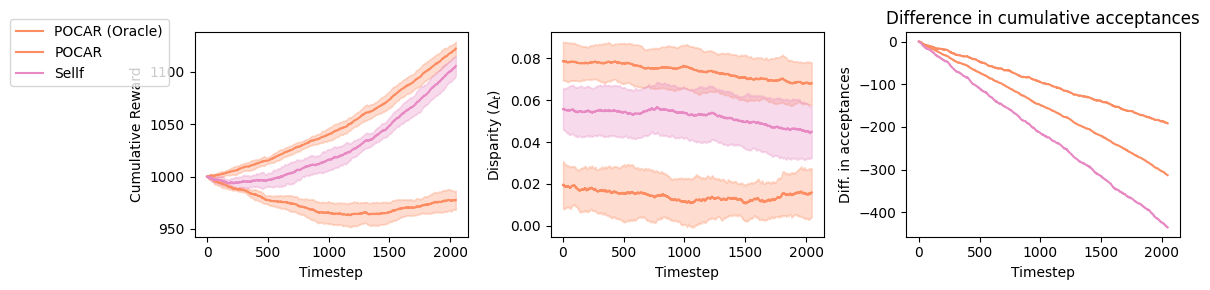

In [64]:
df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]


for i in range(len(df_list)):
    # create column with number of acceptions for each group
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)
    
    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()

    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

    
def legend_func(alg_name):
    if "serew" in alg_name:
        return "Sellf"
    if "ppo" in alg_name:
        return "PPO"
    if "pocar_full" in alg_name:
        return "POCAR (Oracle)"
    if "pocar" in alg_name:
        return "POCAR"
    return alg_name


def color_func(alg_name):
    if "serew" in alg_name:
        return "#e78ac3"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#fc8d62"


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index, df["resource"]["mean"], label=legend_func(alg), color=color_func(alg)
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    axs[1].plot(
        df.index, df["delta"]["mean"], label=legend_func(alg), color=color_func(alg)
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    # calculate the difference in acceptance
    diff_accept = df["n_accept_g0"]["mean"] - df["n_accept_g1"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=legend_func(alg),
        color=color_func(alg),
    )


for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_ylabel("Cumulative Reward")
axs[1].set_ylabel("Disparity ($\Delta_t$)")
axs[2].set_ylabel("Diff. in acceptances")
axs[2].set_title("Difference in cumulative acceptances")


# place legend outside the left plot
axs[0].legend(loc="center left", bbox_to_anchor=(-0.7, 0.9))
plt.tight_layout()
plt.savefig("figures/enem_quali.pdf", bbox_inches='tight')
plt.show()


### Accuracy

In [58]:
env_name = "fico_equal"
mu_type = "accuracy"
alg_names = []
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"serew(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending = False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:5 beta_2:5),0.065155,0.009576,0.065155,0.009576,1408.20,17.001438,0.011177,0.557676,0.934845,0.765649
pocar(beta,pocar(beta_1:1 beta_2:1),0.069418,0.005407,0.042548,0.011650,1590.78,15.113923,0.131084,0.648790,0.930582,1.275141
serew(beta,serew(beta_1:1 beta_2:0.1),0.035830,0.004886,0.026097,0.006417,1589.80,15.824032,0.186940,0.666252,0.964170,2.092290


# ENEM

## Comparative

### Equality of opportunity

In [59]:
env_name = "enem"
mu_type = "tpr"
alg_names = []
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"serew(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending = False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:1 beta_2:1),0.081568,0.017064,0.081568,0.017064,1128.90,7.085980,0.269567,0.405298,0.918432,0.747417
pocar(beta,pocar(beta_1:2 beta_2:5),0.205838,0.012744,0.000000,0.000000,1138.55,5.609763,0.188769,0.404892,0.794162,-0.360403
serew(beta,serew(beta_1:1 beta_2:0.05),0.046787,0.012285,0.075672,0.016839,1122.40,8.809086,0.444510,0.550501,0.953213,0.867958


### Accuracy

In [60]:
env_name = "enem"
mu_type = "accuracy"
alg_names = []
for beta_1 in [1, 2, 5, 10]:
    for beta_2 in [0, 0.05, 0.1]:
        alg_names.append(f"serew(beta_1:{beta_1} beta_2:{beta_2})")
    for beta_2 in [1, 2, 5, 10]:
        alg_names.append(f"pocar(beta_1:{beta_1} beta_2:{beta_2})")
        alg_names.append(f"pocar_full(beta_1:{beta_1} beta_2:{beta_2})")
results = summarize_hyperparam(env_name, mu_type, alg_names)
results.sort_values("score", ascending = False).groupby("alg_simplified").first()

,alg,delta,delta_std,delta_obs,delta_obs_std,reward,reward_std,accept_g0,accept_g1,minus_delta,score
alg_simplified,,,,,,,,,,,
pocar,pocar_full(beta_1:1 beta_2:1),0.073959,0.009046,0.073959,0.009046,1122.05,6.672706,0.178983,0.391201,0.926041,0.055388
pocar(beta,pocar(beta_1:10 beta_2:1),0.014445,0.008842,0.112310,0.009655,977.50,8.885069,0.475916,0.501899,0.985555,0.387730
serew(beta,serew(beta_1:5 beta_2:0.1),0.052116,0.011456,0.036853,0.010978,1105.45,9.405820,0.532798,0.747604,0.947884,0.997666


In [61]:
selected_algs = results.sort_values("score", ascending=False).groupby("alg_simplified").first()["alg"].tolist()

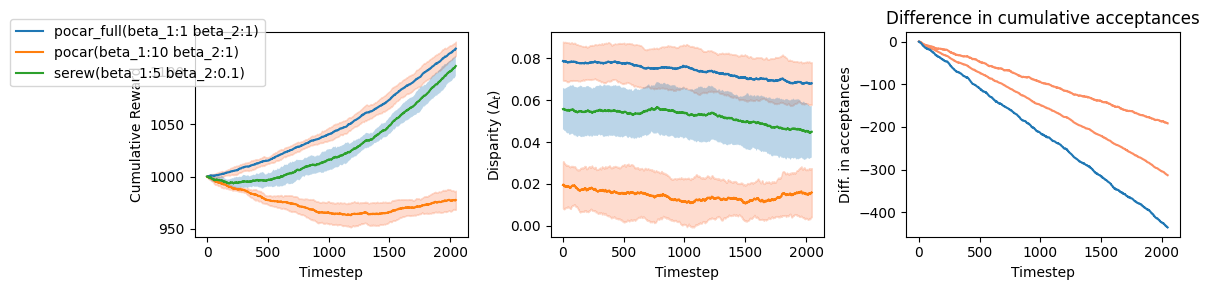

In [62]:
df_list = [
    pd.read_csv(f"experiments/{env_name}/{mu_type}/{alg}/eval/eval_data.csv")
    for alg in selected_algs
]
for i in range(len(df_list)):
    # create column with number of acceptions for each group
    df_list[i]["accept_g0"] = df_list[i]["action"] * (df_list[i]["group_id"] == 0)
    df_list[i]["accept_g1"] = df_list[i]["action"] * (df_list[i]["group_id"] == 1)
    
    # for each ep, compute cumulative sum of accept_g0 and accept_g1
    df_list[i]["n_accept_g0"] = df_list[i].groupby("ep")["accept_g0"].cumsum()
    df_list[i]["n_accept_g1"] = df_list[i].groupby("ep")["accept_g1"].cumsum()
    df_list[i]["delta"] = df_list[i]["delta"].abs()

    df_list[i] = (
        df_list[i]
        .groupby("t")
        .agg(
            {
                "resource": ["mean", "std"],
                "delta": ["mean", "std"],
                "n_accept_g0": ["mean", "std"],
                "n_accept_g1": ["mean", "std"],
            }
        )
    )

    
def legend_func(alg_name):
    return alg_name
    if "sellf" in alg_name:
        return "Sellf"
    if "ppo" in alg_name:
        return "PPO"
    if "pocar" in alg_name:
        return "POCAR"
    return alg_name


def color_func(alg_name):
    if "sellf" in alg_name:
        return "#e78ac3"
    if "ppo" in alg_name:
        return "#8da0cb"
    if "pocar" in alg_name:
        return "#fc8d62"


fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
for alg, df in zip(selected_algs, df_list):
    axs[0].plot(
        df.index, df["resource"]["mean"], label=legend_func(alg) #, color=color_func(alg)
    )
    axs[0].fill_between(
        df.index,
        df["resource"]["mean"] - df["resource"]["std"],
        df["resource"]["mean"] + df["resource"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    axs[1].plot(
        df.index, df["delta"]["mean"], label=legend_func(alg) #, color=color_func(alg)
    )
    axs[1].fill_between(
        df.index,
        df["delta"]["mean"] - df["delta"]["std"],
        df["delta"]["mean"] + df["delta"]["std"],
        alpha=0.3,
        color=color_func(alg),
    )

    # calculate the difference in acceptance
    diff_accept = df["n_accept_g0"]["mean"] - df["n_accept_g1"]["mean"]
    axs[2].plot(
        df.index,
        diff_accept,
        label=legend_func(alg),
        color=color_func(alg),
    )


for i in range(3):
    axs[i].set_xlabel("Timestep")

axs[0].set_ylabel("Cumulative Reward")
axs[1].set_ylabel("Disparity ($\Delta_t$)")
axs[2].set_ylabel("Diff. in acceptances")
axs[2].set_title("Difference in cumulative acceptances")


# place legend outside the left plot
axs[0].legend(loc="center left", bbox_to_anchor=(-0.7, 0.9))
plt.tight_layout()
#plt.savefig("figures/fico_tpr.pdf", bbox_inches='tight')
plt.show()
